# The Hidden Reality of the Working Hungry
### Uncovering the Invisible Economic Squeeze on American Families

The common view of hunger often focuses on people who are out of work or have no resources at all. However, the information in this study reveals a much more complex and quiet struggle.

This exploration looks at the Invisible Squeeze. This is a situation where households have jobs and ways to get around, but they still struggle to put enough food on the table. By looking at the facts, we show:

The Job Paradox: Why having a paycheck is not always enough to prevent hunger.
The Safety Net Gap: The families who earn too much to get government help but too little to afford all their needs.
The Life Factors: How schooling and the number of people in a home change a family's ability to stay secure.

### The Data Foundation
This story is built on more than 4,800 household records. To understand the full picture of hunger, we look at several key areas of life:

1. Money and Jobs: We look at income levels and whether a household has a working adult.
2. Family and Home: We look at the size of the family and whether there are children or seniors in the house.
3. Help and Support: We look at who is using food pantries or government food assistance.
4. Getting Around: We look at who owns a car and how that changes their ability to stay food secure.
5. Education and Background: We look at how schooling and community factors play a role in a family's stability.

## Setup and load data

We load:
- The case dataset (one row per household)
- The case data dictionary (variable definitions and notes)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

DATA_PATH = r"Case_dataset.csv"
DICT_PATH = r"Case_data_dictionary.csv"

df = pd.read_csv(DATA_PATH)
dd = pd.read_csv(DICT_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4826, 38)


,hhnum,food_insecure_flag_adult,adltfscat,foodsufficient,poverty_ratio,poverty_band,snap_any,foodpantry,household_size,num_adults,num_children,num_elderly,employed_adults,any_employed_adult,head_age,head_sex,head_hispanic,head_racecat,head_educcat,head_employment,region,rural,nonmetro,anyvehicle,vehiclenum,caraccess,dist_sm,dist_cs,dist_walmart,nearsnap_dist,nearff_dist,nearnonff_dist,fah_event_count,fah_storetype_unique,fafh_event_count,fafh_schoolmeal_events,targetgroup,hhwgt
0,100012,0,2,2,2.073601,2.0-4.0 (moderate),False,0,5,3,2,0,3,1,47.5,1,0,1,3.0,1,3,1,1,1,2,-996,0.33,1.03,0.90,0.33,0.30,0.30,6.0,0.0,30.0,0.0,4,6056.913412
1,100015,0,2,3,1.289167,1.0-1.3 (near poverty),True,0,1,1,0,0,0,0,62.5,1,0,2,3.0,5,3,0,0,1,1,-996,1.05,0.26,1.70,0.19,0.21,0.20,6.0,0.0,10.0,0.0,2,26741.184558
2,100024,0,2,2,3.985063,2.0-4.0 (moderate),False,0,2,1,1,0,1,1,47.5,2,0,1,4.0,1,2,0,0,1,2,-996,4.77,1.72,3.56,0.90,0.85,0.37,3.0,0.0,7.0,0.0,3,31665.579066
3,100026,1,3,2,1.427627,1.3-2.0 (low income),False,0,3,3,0,0,1,1,27.5,2,0,1,2.0,2,3,1,0,1,1,-996,12.30,7.20,11.12,1.72,10.93,1.70,9.0,0.0,10.0,0.0,2,5686.761977
4,100028,1,4,3,1.373490,1.3-2.0 (low income),True,0,7,5,2,0,3,1,47.5,2,0,1,1.0,1,1,0,0,1,1,-996,1.17,0.41,4.17,0.41,0.86,0.46,7.0,0.0,7.0,0.0,4,1067.431417


In [2]:
dd.head(12)


,variable,label,description,type,notes
0,hhnum,Household ID,Unique household identifier used to merge files.,integer,NaN
1,food_insecure_flag_adult,Food insecure (adult category),1 if adult food security category indicates lo...,binary,"Derived: adltfscat in {3,4} => 1"
2,adltfscat,Adult food security category,Adult food security category (4-level). Lower ...,categorical (1-4),"Typical interpretation: 1=High, 2=Marginal, 3=..."
3,foodsufficient,Food sufficiency indicator,Household-reported food sufficiency measure.,categorical,1 often corresponds to food sufficient; other ...
4,poverty_ratio,Poverty ratio (cleaned),Household percent of poverty guideline divided...,numeric,Example: 1.0 means at the poverty guideline; 2...
5,poverty_band,Income band from poverty ratio,Income band derived from poverty_ratio for eas...,categorical,"Bands: <=1.0, 1.0-1.3, 1.3-2.0, 2.0-4.0, >4.0"
6,snap_any,SNAP participation indicator,1 if household indicates SNAP participation ac...,binary,Derived from snap1..snap8
7,foodpantry,Food pantry use indicator,Indicator related to whether household used a ...,categorical/binary,NaN
8,household_size,Household size,Number of individuals listed in the household ...,integer,Aggregated from individual file
9,num_adults,Number of adults,Count of household members age 18+.,integer,Aggregated from individual file


## Quick data quality check

We check missingness. If missingness exists, you can decide whether to impute, drop, or treat “missing” as its own category (often reasonable for survey-style data).


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing


head_educcat    3
dtype: int64

In [4]:
# Create mapping dictionaries for categorical variables
MAPPINGS = {
    "head_sex": {1: "Male", 2: "Female"},
    "region": {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"},
    "rural": {0: "Urban", 1: "Rural"},
    "nonmetro": {0: "Metro", 1: "Non-Metro"},
    "any_employed_adult": {0: "No Employed Adults", 1: "At Least One Employed Adult"},
    "anyvehicle": {0: "No Vehicle", 1: "Has Vehicle"},
    "snap_any": {False: "Not on SNAP", True: "On SNAP"},
    "head_educcat": {
        1.0: "Less than High School",
        2.0: "High School / GED",
        3.0: "Some College / Assoc.",
        4.0: "College Graduate",
        5.0: "Graduate Degree",
        6.0: "Advanced Professional"
    }
}

## The Scale of the Problem

To understand the reality of the working hungry we first need to look at the overall level of hunger in the homes we studied.

A home is considered food insecure when the adults in the house do not have enough money or other resources to get the food they need. This measurement is the foundation for our entire story.

The charts below show:
The total number of homes that are secure versus those that are struggling.
The percentage of the community that faces these daily challenges.

This gives us a starting point for seeing how many people are living in the invisible squeeze.

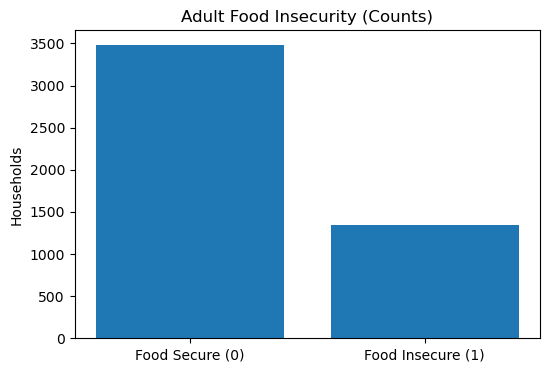

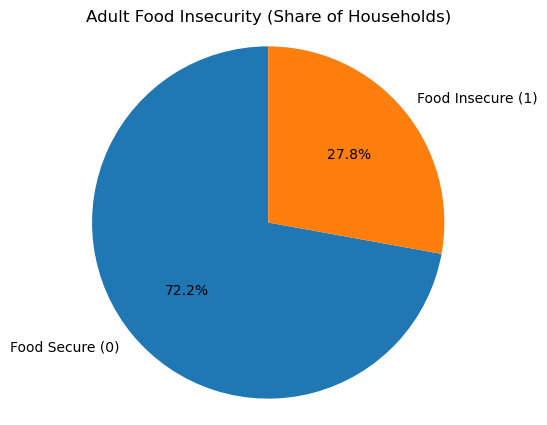

(food_insecure_flag_adult
 0    3482
 1    1344
 Name: count, dtype: int64,
 food_insecure_flag_adult
 0    0.722
 1    0.278
 Name: count, dtype: float64)

In [5]:
outcome = "food_insecure_flag_adult"

counts = df[outcome].value_counts().sort_index()
labels = ["Food Secure (0)", "Food Insecure (1)"]

# Bar chart (counts)
plt.figure(figsize=(6,4))
plt.bar(labels, counts.values)
plt.title("Adult Food Insecurity (Counts)")
plt.ylabel("Households")
plt.xticks(rotation=0)
plt.show()

# Pie chart (share)
plt.figure(figsize=(5,5))
plt.pie(counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Adult Food Insecurity (Share of Households)")
plt.axis("equal")
plt.show()

counts, (counts / counts.sum()).round(3)


## The Baseline: Hunger is Not a Fringe Issue

The first step in understanding the invisible squeeze is acknowledging how common it is. The data reveals that 27.8% of households are food insecure.

This means that roughly **one in every four homes** struggles with reliable access to enough food. 

When we look at this through the lens of a neighborhood, hunger isn't just an isolated problem affecting a few people on the edges of society. It is a widespread reality for a significant portion of the community. This finding changes how we think about solutions:

* It is not enough to have a small, temporary food drive.
* Because the problem affects 25% of the population, we need permanent, systematic support.
* The challenge is large enough that we likely walk past someone every day who is facing this struggle.

### Key Insight
Hunger is common enough to be a community-wide crisis, yet quiet enough that it often goes unnoticed. This scale of 1-in-4 households sets the stage for our main question: If so many people are struggling, who are they, and why isn't the current system reaching them?

### Summary
* Food insecurity impacts about 28% of households.
* The problem is widespread, not isolated.
* This baseline establishes that hunger is a major economic factor in the community.

## 2) Food Security Category Distribution

The variable `adltfscat` breaks households into four levels of adult food security:

1 = High food security

2 = Marginal food security

3 = Low food security

4 = Very Low food security

Unlike the binary food insecurity flag, this variable helps us understand how severe food-related hardship is across households.



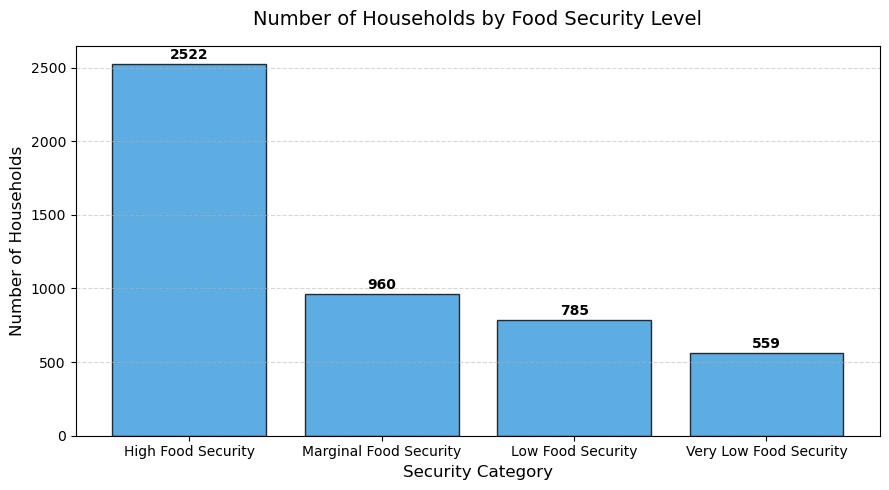

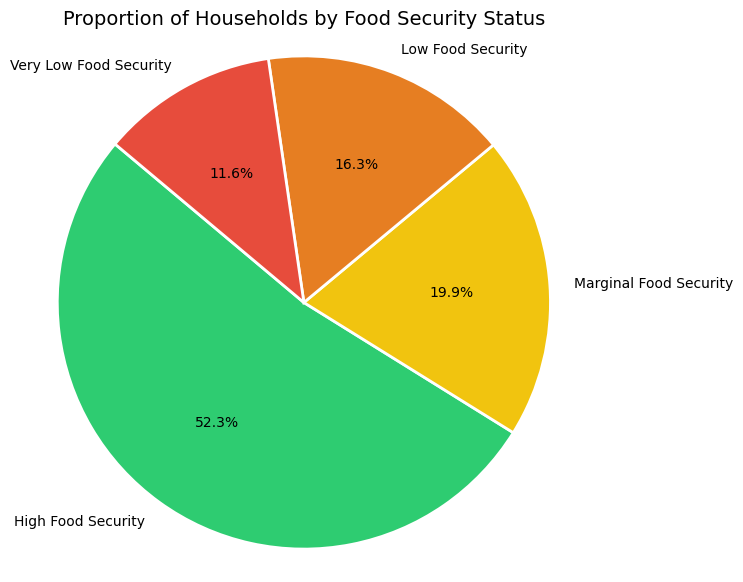

,Number of Households
adltfscat,
High Food Security,2522
Marginal Food Security,960
Low Food Security,785
Very Low Food Security,559


In [7]:
# 1. Define the descriptive labels
ADULT_FS_LABELS = {
    1: "High Food Security",
    2: "Marginal Food Security",
    3: "Low Food Security",
    4: "Very Low Food Security"
}

# 2. Prepare the data
sev = "adltfscat"
sev_counts = df[sev].value_counts().sort_index()
# Create the text labels for the charts
mapped_labels = [ADULT_FS_LABELS.get(i, i) for i in sev_counts.index]

# 3. Bar Chart (Counts) - Updated with labels and visual polish
plt.figure(figsize=(9, 5))
bars = plt.bar(mapped_labels, sev_counts.values, color='#3498db', edgecolor='black', alpha=0.8)

# Add exact counts on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 15, f'{int(yval)}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title("Number of Households by Food Security Level", fontsize=14, pad=15)
plt.ylabel("Number of Households", fontsize=12)
plt.xlabel("Security Category", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Pie Chart (Share) - Updated with labels and color coding
# Colors: Green (Safe) to Red (Critical)
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

plt.figure(figsize=(7, 7))
plt.pie(sev_counts.values, labels=mapped_labels, autopct="%1.1f%%", 
        startangle=140, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title("Proportion of Households by Food Security Status", fontsize=14)
plt.axis("equal")
plt.show()

# Display the summary table with labels
sev_summary = sev_counts.to_frame(name='Number of Households')
sev_summary.index = sev_summary.index.map(ADULT_FS_LABELS)
sev_summary

## The Spectrum of Struggle: Not All Hunger Looks the Same

When we talk about the "Invisible Squeeze," it is important to realize that hunger is not a simple "yes" or "no" situation. It is a spectrum. By breaking the community into four levels, we can see exactly where families are starting to slip.

### The Two Lanes of Concern
The data shows that we need to think in two different ways about helping our neighbors:

1. **The Prevention Lane (Marginal Security):** These are families who might look stable on the surface. They have food today, but they are living on a knife-edge. One unexpected car repair or medical bill could push them into a crisis. They are "at risk" and need support to stay stable.

2. **The Crisis Lane (Low and Very Low Security):** These families are already in the middle of the squeeze. They are likely skipping meals, reducing how much they eat, or choosing between buying groceries and paying rent. They need immediate and intensive help.



### Key Insight
Food hardship is not just about the extreme cases you see on the news. The "Marginal" group is a large, hidden segment of our community. If we only focus on people in total crisis, we miss the opportunity to help these families before they lose their stability entirely.

### Summary
* Hunger is a spectrum, not a single category.
* Marginal households are the "hidden" at-risk group.
* Low and Very Low households are in active crisis.

This leads us to the next part of our story: What are the specific life constraints—like income, family size, or jobs—that push a family out of stability and into these danger zones?

## 3) Food Insecurity Rate by Poverty Band

The chart compares the share of food-insecure households within each poverty band. 

Poverty bands group households by their income relative to the poverty line (for example, ≤1.0 means at or below the poverty threshold).

This helps answer a core question: How strongly is food insecurity tied to economic hardship?


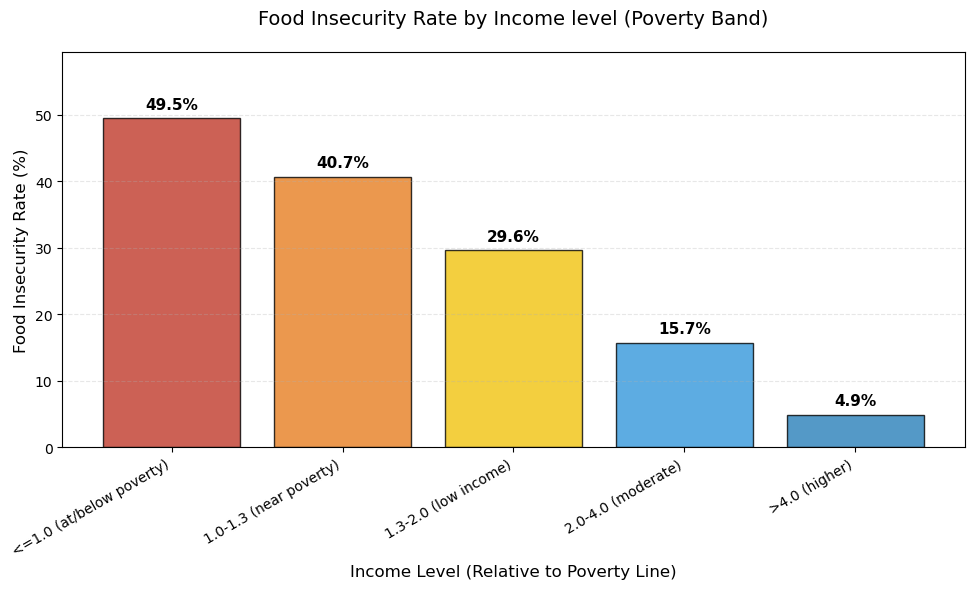

,Insecurity Rate (%)
poverty_band,
<=1.0 (at/below poverty),49.456976
1.0-1.3 (near poverty),40.704501
1.3-2.0 (low income),29.618474
2.0-4.0 (moderate),15.722802
>4.0 (higher),4.871795


In [8]:
# 1. Define the logical economic order for the bands
poverty_order = [
    "<=1.0 (at/below poverty)", 
    "1.0-1.3 (near poverty)", 
    "1.3-2.0 (low income)", 
    "2.0-4.0 (moderate)", 
    ">4.0 (higher)"
]

# 2. Prepare the data
band = "poverty_band"
tmp = df[[band, outcome]].dropna()

# Calculate rates and reindex to the logical order defined above
rate_by_band = tmp.groupby(band)[outcome].mean().reindex(poverty_order) * 100

# 3. Visualization
plt.figure(figsize=(10, 6))
# Using a gradient from dark red (high risk) to light blue (low risk)
colors = ['#c0392b', '#e67e22', '#f1c40f', '#3498db', '#2980b9']

bars = plt.bar(rate_by_band.index, rate_by_band.values, color=colors, edgecolor='black', alpha=0.8)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title("Food Insecurity Rate by Income level (Poverty Band)", fontsize=14, pad=20)
plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
plt.xlabel("Income Level (Relative to Poverty Line)", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, max(rate_by_band.values) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Display as a clean summary table
rate_summary = rate_by_band.to_frame(name='Insecurity Rate (%)')
rate_summary

## Income and the Invisible Squeeze

The most direct part of the invisible squeeze is the amount of money a family brings home. As income drops, the struggle to afford basic needs like food grows much more difficult.

The most intense hardship is found in households living at or below the official poverty line. In this group, nearly half of all families struggle with food. However, a major part of the story is the group of people living just above that line. These families earn slightly more than the official limit but are still in a very dangerous position. Their high rate of hunger shows that earning a little bit more is often not enough to find security.

Even as we look at families with moderate incomes, the problem does not entirely go away. This suggests that the cost of living is squeezing even those who might appear to be doing okay on the surface.

Key Insight
Hunger is a direct result of financial pressure. While the poorest families face the most risk, the danger zone reaches much further than the official poverty line. Many families who may not qualify for help are still caught in the squeeze.

Summary
The highest risk is found in households at or just above the poverty line.
Small increases in income do not automatically solve the problem of hunger.
Higher income lowers the risk but does not protect everyone.

This leads to the next question in our story. Within these income groups, what other factors make a family more likely to struggle? We will now look at how the number of children or seniors in a house changes a family's stability.

## 4) Food Insecurity Rate by Household Size

Household structure can influence food insecurity because income and resources must be shared across members. Larger households or those with more dependents may face greater financial strain and food demand.

To explore this, we examine three household composition indicators:

- Household size

- Number of children

- Number of elderly members

Together, these variables help identify which household structures may be more vulnerable to food insecurity.


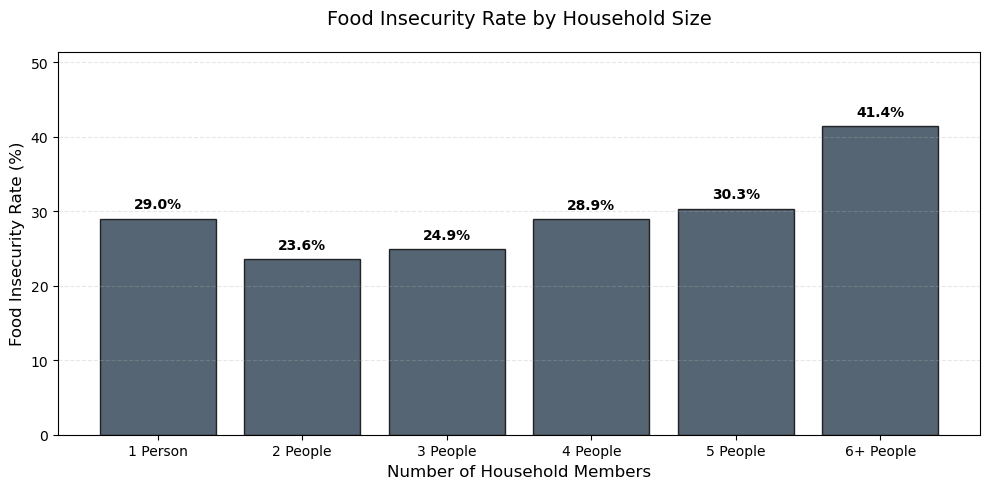

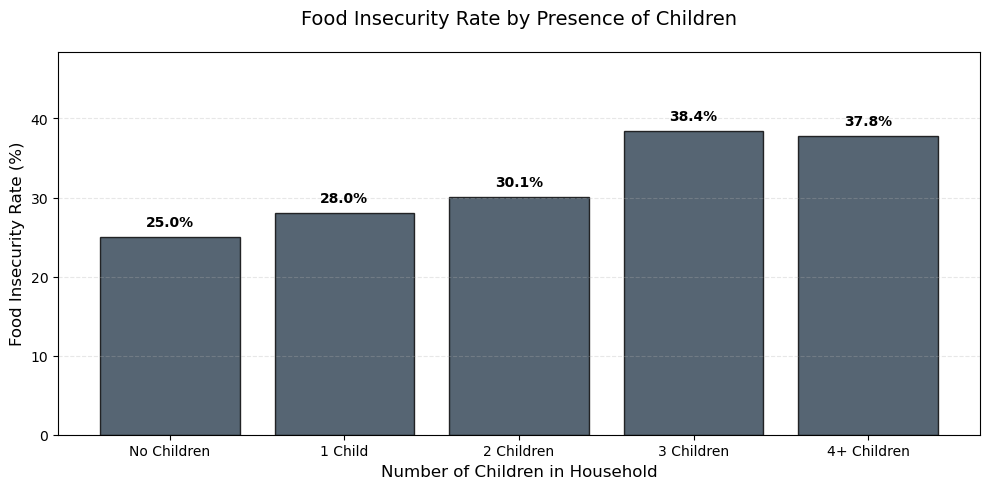

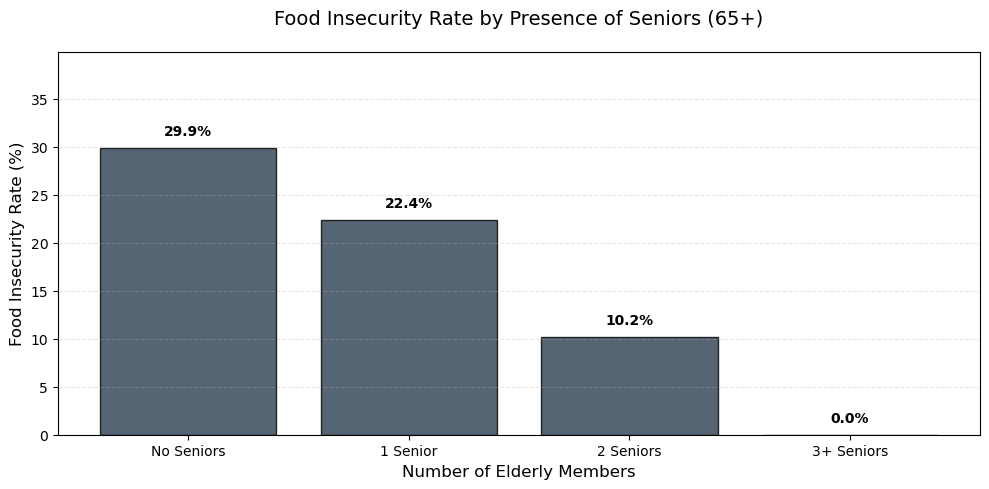

bin
No Seniors    29.9
1 Senior      22.4
2 Seniors     10.2
3+ Seniors     0.0
Name: food_insecure_flag_adult, dtype: float64

In [9]:
def rate_bar_by_binned_numeric(df, xcol, ycol, bins, labels, title, xlabel):
    """
    Plots a binned bar chart with human-readable labels and percentages.
    """
    tmp = df[[xcol, ycol]].dropna().copy()
    # Apply the bins and the custom labels
    tmp["bin"] = pd.cut(tmp[xcol], bins=bins, labels=labels, include_lowest=True)
    
    # Calculate rates as percentages
    rate = tmp.groupby("bin", observed=True)[ycol].mean() * 100
    
    plt.figure(figsize=(10, 5))
    # Use a friendly professional blue
    bars = plt.bar(rate.index.astype(str), rate.values, color='#2c3e50', edgecolor='black', alpha=0.8)
    
    # Add percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

    plt.title(title, fontsize=14, pad=20)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
    plt.xticks(rotation=0) # Kept at 0 for readability if labels are short
    plt.ylim(0, max(rate.values) + 10)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return rate.round(1)

# 1. Household Size - Groups individuals for better story context
rate_bar_by_binned_numeric(
    df, "household_size", outcome,
    bins=[0, 1, 2, 3, 4, 5, 50],
    labels=["1 Person", "2 People", "3 People", "4 People", "5 People", "6+ People"],
    title="Food Insecurity Rate by Household Size",
    xlabel="Number of Household Members"
)

# 2. Number of Children - Highlights the vulnerability of families
rate_bar_by_binned_numeric(
    df, "num_children", outcome,
    bins=[-0.1, 0, 1, 2, 3, 50],
    labels=["No Children", "1 Child", "2 Children", "3 Children", "4+ Children"],
    title="Food Insecurity Rate by Presence of Children",
    xlabel="Number of Children in Household"
)

# 3. Number of Elderly - Shows the 'Senior Safety Net' effect
rate_bar_by_binned_numeric(
    df, "num_elderly", outcome,
    bins=[-0.1, 0, 1, 2, 50],
    labels=["No Seniors", "1 Senior", "2 Seniors", "3+ Seniors"],
    title="Food Insecurity Rate by Presence of Seniors (65+)",
    xlabel="Number of Elderly Members"
)

## More People Mean a Tighter Squeeze

As more people live in a home the budget for food has to stretch further. The data shows that as the number of people in a house grows the risk of hunger rises as well. Homes with one or two people have a lower risk. However once a household reaches six or more members the risk of hunger jumps significantly. This shows that larger families face much more pressure on their limited resources.

### Key Insight
Larger families are more vulnerable because their daily needs are so high. Even with a steady income the cost of feeding many people can quickly become more than a family can handle.

## The Cost of Raising a Family

The number of children in a home is one of the clearest signs of food stress. Families with no children have a lower risk of hunger. As the number of children increases the rate of food insecurity rises steadily. Families with three or more children face the highest risk. This is because children increase the demand for food and other daily expenses which can quickly overwhelm a family budget.

### Key Insight
Raising a large family in today's economy is a major part of the invisible squeeze. Programs that focus on school meals and child nutrition are essential because they help families manage the high costs of supporting several children.

## The Stability of Older Adults

We see a different pattern when we look at older adults. Homes with seniors often have a lower risk of hunger than homes without them. This may be because many older adults have more stable sources of money like social security or pensions. This steady income acts as a shield that protects the home from the sudden changes that often cause hunger. 

### Key Insight
While families with children are struggling older adults appear to have more protection from the invisible squeeze. This suggests that having a reliable and steady source of money is a powerful tool for preventing hunger.

## How Family Makeup Drives Hunger

The structure of a family is a major factor in the invisible squeeze. Larger households and those with many children are at the highest risk because their daily expenses are so high. On the other hand homes with seniors are often more stable. This tells us that hunger is not just about income levels but also about how many people depend on that money and how stable that money is.

## 5) Assistance programs: SNAP and food pantry

We show the share food insecure within:
- SNAP participants vs non-participants
- Food pantry users vs non-users

Food assistance programs are intended to reduce food insecurity. In this section, we examine how food insecurity rates differ among households that participate in SNAP and those that use food pantries.

These programs serve different roles: SNAP provides ongoing income-based food assistance, while food pantries often provide emergency or supplemental food support.


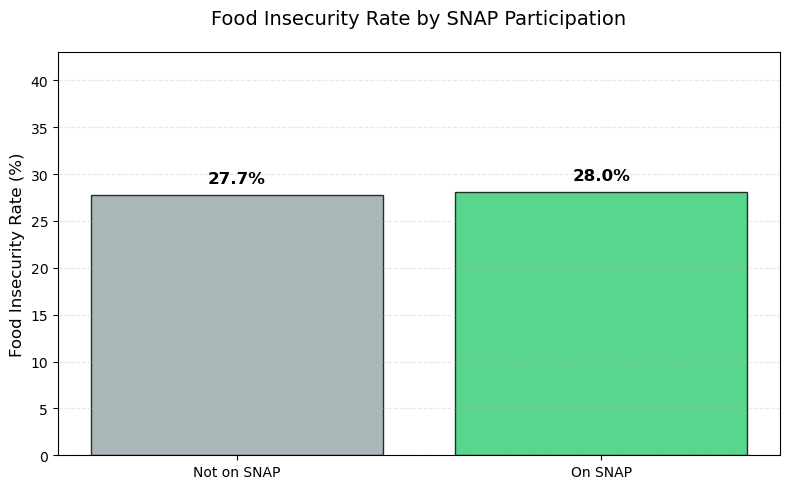

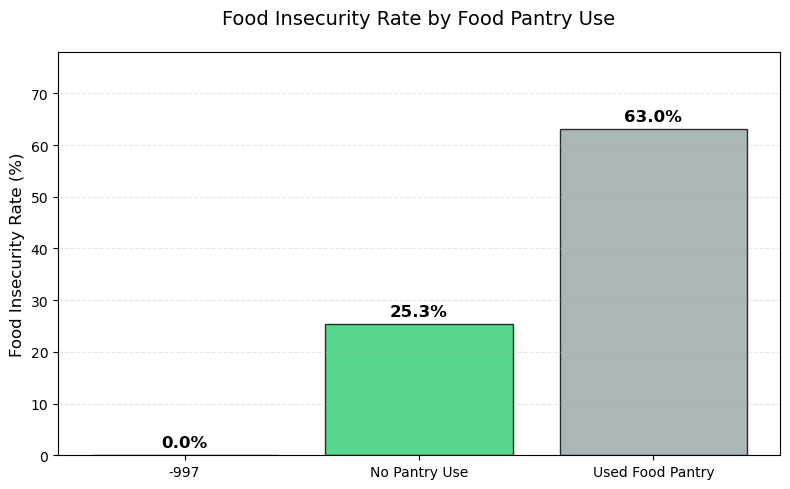

In [21]:
# 1. Define specific labels for assistance programs
ASSISTANCE_MAPPINGS = {
    "snap_any": {0: "Not on SNAP", 1: "On SNAP", False: "Not on SNAP", True: "On SNAP"},
    "foodpantry": {0: "No Pantry Use", 1: "Used Food Pantry"}
}

# 2. Updated binary comparison function
def rate_bar_assistance(df, xcol, ycol, title):
    """
    Plots a comparison of food insecurity rates for binary assistance variables.
    """
    tmp = df[[xcol, ycol]].dropna().copy()
    
    # Calculate rates as percentages
    rate = tmp.groupby(xcol)[ycol].mean() * 100
    
    # Map binary/boolean values to text labels
    labels = [ASSISTANCE_MAPPINGS[xcol].get(val, str(val)) for val in rate.index]
    
    plt.figure(figsize=(8, 5))
    # Using contrasting colors to show the two groups
    colors = ['#95a5a6', '#2ecc71'] # Gray for 'No', Green for 'Yes'
    
    bars = plt.bar(labels, rate.values, color=colors, edgecolor='black', alpha=0.8)
    
    # Add percentage labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

    plt.title(title, fontsize=14, pad=20)
    plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
    plt.ylim(0, max(rate.values) + 15) # Room for labels
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return rate.round(1)

# 3. Implementation
snap_rate = rate_bar_assistance(df, "snap_any", outcome, "Food Insecurity Rate by SNAP Participation")
pantry_rate = rate_bar_assistance(df, "foodpantry", outcome, "Food Insecurity Rate by Food Pantry Use")

## The Gap in the Safety Net

While programs like food stamps are meant to help people in need we find a large gap between those who are hungry and those who are getting help. This is a major part of the invisible squeeze. Many families are struggling to buy food but are not connected to official support systems.

### Why Government Help Does Not Tell the Whole Story

When we look at families getting food stamps compared to those who are not we see a surprising result. The rate of hunger is almost exactly the same for both groups. About 28 percent of families in both groups struggle to get enough food. 

This tells us two important things. First those getting help are likely facing deep challenges and the support is helping them stay afloat. Second there are many hungry families who are not getting any government help at all. This might be because they earn slightly too much to qualify or because the process is too difficult. These are the families caught in the middle.

Key Insight
You cannot tell if a family is hungry just by looking at whether they get government help. There are just as many hungry families outside the system as there are inside it. We must look beyond official records to find the neighbors who are quietly struggling.

### Where the Squeeze is Most Visible

While government help is spread out across many families food pantries show us where the pressure is most intense. The difference here is very clear. Families who do not use food pantries have a much lower rate of hunger. On the other hand more than 60 percent of the families who visit a food pantry are facing serious hunger.

Food pantries often act as the last line of defense for families in a crisis. When the paycheck and the government help are both not enough the food pantry is where the most desperate families turn for help.

Key Insight
Visiting a food pantry is a very strong sign that a family is in a crisis. These families are more than twice as likely to be hungry as those who do not use them. This makes the local food pantry a critical place to reach the people who need help the most.

### Summary
The safety net is not catching everyone. Many hungry families are not on government programs which means they are facing the squeeze alone. Community resources like food pantries are essential because they catch the people who are falling through the cracks of the official system.

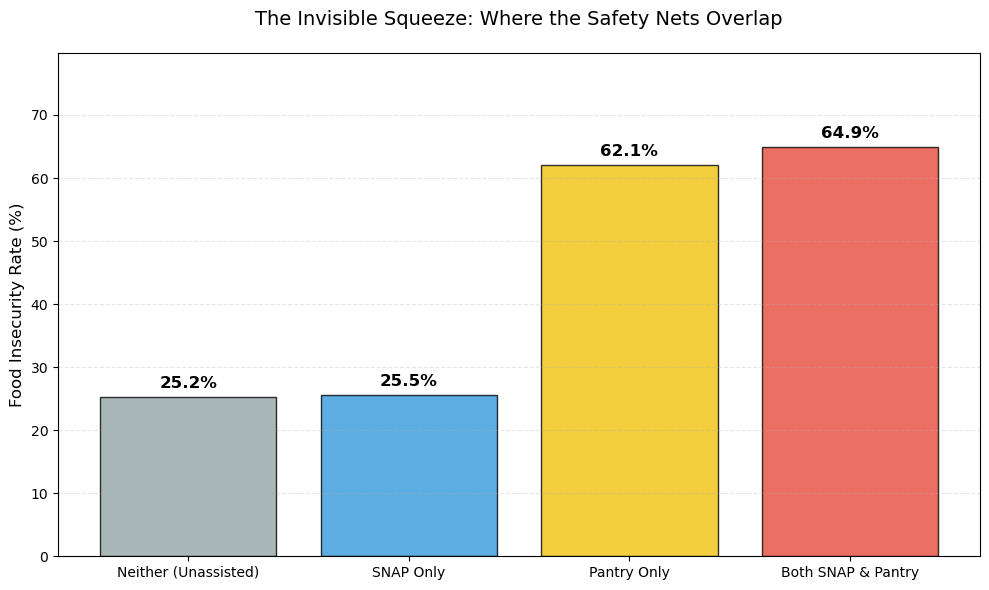

In [33]:
# 1. Define the four intersection groups
def get_assistance_group(row):
    # Check SNAP status and Pantry status
    snap = row['snap_any']
    pantry = row['foodpantry']
    
    if snap == True and pantry == 1:
        return "Both SNAP & Pantry"
    elif snap == True and pantry == 0:
        return "SNAP Only"
    elif snap == False and pantry == 1:
        return "Pantry Only"
    elif snap == False and pantry == 0:
        return "Neither (Unassisted)"
    else:
        return "Unknown"

# Apply the grouping to the data
df['assistance_group'] = df.apply(get_assistance_group, axis=1)

# 2. Calculate rates for the story
group_rates = df[df['assistance_group'] != "Unknown"].groupby('assistance_group')[outcome].mean() * 100

# Reorder them to show the progression of support
story_order = ["Neither (Unassisted)", "SNAP Only", "Pantry Only", "Both SNAP & Pantry"]
ordered_rates = group_rates.reindex(story_order)

# 3. Create the Visualization
plt.figure(figsize=(10, 6))
# Colors: Grey (Unassisted), Blue (Government), Yellow (Community), Red (Crisis)
colors = ['#95a5a6', '#3498db', '#f1c40f', '#e74c3c']

bars = plt.bar(ordered_rates.index, ordered_rates.values, color=colors, edgecolor='black', alpha=0.8)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title("The Invisible Squeeze: Where the Safety Nets Overlap", fontsize=14, pad=20)
plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
plt.ylim(0, max(ordered_rates.values) + 15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Where the Safety Nets Overlap

By looking at government help and community help together we can see exactly who is falling through the cracks. This chart shows us the four different ways families are trying to survive the invisible squeeze.

### The Hidden Middle: The Unassisted
The most important group for our story is the "Neither" group. These are families who are not on government food stamps and do not visit food pantries. Even without any help one in every four of these families is hungry. This is the largest group in our study. They are the true "Working Hungry" who are facing the squeeze entirely on their own.

### The SNAP Paradox
We see that families who only get government help (SNAP Only) have almost the exact same rate of hunger as those who get no help at all. This suggests that while the program is a vital lifeline it is often only enough to keep a family from falling further behind. It does not "solve" the problem of hunger for them.

### The Red Flag: Pantry Usage
The groups that use food pantries have much higher rates of hunger regardless of whether they get government help or not. More than 60 percent of people visiting a pantry are in an active crisis. This tells us that families only turn to a food pantry when their situation has become desperate. 

The fact that many people are in the "Pantry Only" group shows that there are families in deep crisis who are still not connected to government programs. This might be because they are ineligible for help even though their need is very high.

Key Insight
Government help is a baseline for many but it is often not enough to end the squeeze. Community food pantries are where the most severe hunger is found. The biggest challenge for our community is the millions of families in the "Unassisted" group who are struggling quietly without any support at all.

Summary
One in four unassisted families is hungry.
SNAP help alone does not lower the hunger rate below the community baseline.
Pantry usage is the clearest sign of a family in a deep economic crisis.
Many families in crisis are still not getting official government help.

**Interpretation caution (good to say out loud):**
Assistance participation is often higher among food insecure households because **need drives enrollment**.  
But if you see a meaningful share of *food secure* households in SNAP, you can frame SNAP as a **stabilizer** that may prevent insecurity from worsening.


## 6) Employment stability and food insecurity

We focus on:
- `any_employed_adult` (0/1)
- `head_employment` (categorical coding)

Employment affects food security because it determines income stability, the ability to absorb shocks (unexpected bills, rent increases), and the capacity to plan food purchases consistently. In this section, we examine food insecurity in two ways:

- Whether the household has any employed adult

- The household head’s employment category (which captures differences in employment type or status)


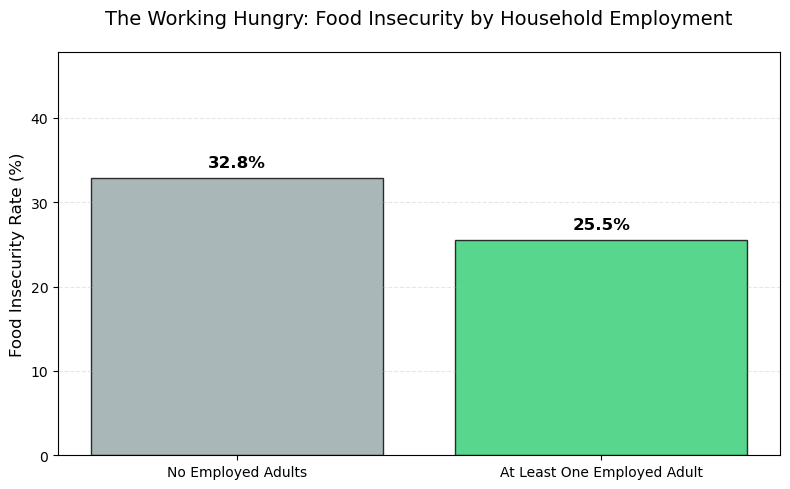

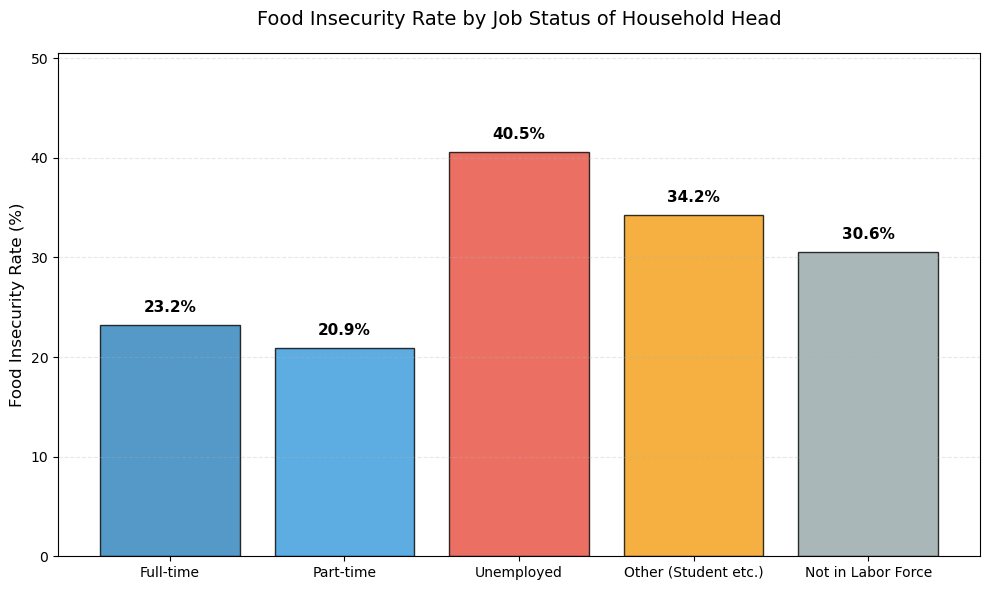

In [17]:
# 1. Expanded mapping dictionary
ASSISTANCE_MAPPINGS = {
    "snap_any": {0: "Not on SNAP", 1: "On SNAP", False: "Not on SNAP", True: "On SNAP"},
    "foodpantry": {0: "No Pantry Use", 1: "Used Food Pantry"},
    "any_employed_adult": {0: "No Employed Adults", 1: "At Least One Employed Adult"}
}

# 2. Updated function with a fallback to prevent KeyErrors
def rate_bar_assistance(df, xcol, ycol, title):
    tmp = df[[xcol, ycol]].dropna().copy()
    rate = tmp.groupby(xcol)[ycol].mean() * 100
    
    # Use the mapping if it exists, otherwise use the raw value
    mapping = ASSISTANCE_MAPPINGS.get(xcol, {})
    labels = [mapping.get(val, f"Group {val}") for val in rate.index]
    
    plt.figure(figsize=(8, 5))
    colors = ['#95a5a6', '#2ecc71'] 
    bars = plt.bar(labels, rate.values, color=colors, edgecolor='black', alpha=0.8)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

    plt.title(title, fontsize=14, pad=20)
    plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
    plt.ylim(0, max(rate.values) + 15)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return rate.round(1)

# 1. Labels for the detailed employment categories
EMPLOYMENT_LABELS = {
    1: "Full-time",
    2: "Part-time",
    3: "Unemployed",
    4: "Other (Student etc.)",
    5: "Not in Labor Force"
}

# 2. The "Working Hungry" Comparison
rate_bar_assistance(df, "any_employed_adult", outcome, "The Working Hungry: Food Insecurity by Household Employment")

# 3. Detailed Employment Status
def plot_head_employment(df, xcol, ycol):
    tmp = df[[xcol, ycol]].dropna().copy()
    rate = tmp.groupby(xcol)[ycol].mean() * 100
    labels = [EMPLOYMENT_LABELS.get(val, f"Code {val}") for val in rate.index]
    
    plt.figure(figsize=(10, 6))
    colors = ['#2980b9', '#3498db', '#e74c3c', '#f39c12', '#95a5a6']
    bars = plt.bar(labels, rate.values, color=colors, edgecolor='black', alpha=0.8)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.title("Food Insecurity Rate by Job Status of Household Head", fontsize=14, pad=20)
    plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
    plt.ylim(0, max(rate.values) + 10)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_head_employment(df, "head_employment", outcome)

## The Myth of the Working Shield

Many people believe that having a job is a complete shield against hunger. While having a working adult in the home does lower the risk it does not solve the problem. In homes where no one has a job the rate of hunger is about 33 percent. But even in homes with at least one working adult the rate is still 25 percent. This means that one out of every four working families is still caught in the invisible squeeze. 

This is the core of our story. Employment is a help but it is not a cure. Many families are doing everything right by going to work every day yet they still cannot afford enough to eat.

### Key Insight
One in four working households is food insecure. This proves that hunger is not just a problem for those without work. It is a reality for millions of people who are active members of the workforce.

## Why the Type of Work Matters

Not all jobs provide the same level of security. When we look closer at the person leading the household we see that the type of work they do changes their risk of hunger. 

Those who are currently unemployed face the highest risk. About 41 percent of these households struggle to get enough food. However even those with full time or part time jobs are not safe. Around 21 to 23 percent of these working leaders still face food insecurity. This suggests that low wages or the high cost of living are making it impossible for a steady paycheck to cover the basic need for food.

### Key Insight
The risk of hunger is highest for those without a job but it remains a significant threat for those with one. The fact that full time workers are struggling shows that the invisible squeeze is affecting the very foundation of the working class.

## Summary of Work and Hunger
Employment is an important piece of the puzzle but it is not the whole solution. A large number of people who go to work every day are still coming home to a house without enough food. This shows that the problem of hunger is deeply tied to the quality of jobs and the rising costs of daily life. Programs that help people find work are important but we also need to support those who are already working but still cannot make ends meet.

## 7) Transportation and access constraints

We examine:
- `anyvehicle` (0/1)
- `caraccess` (coded access)

Access to transportation can influence food security by affecting a household’s ability to reach grocery stores, food pantries, workplaces, and other essential services. Households without reliable transportation may face additional barriers in acquiring food, particularly if stores or assistance programs are located far from their residence.


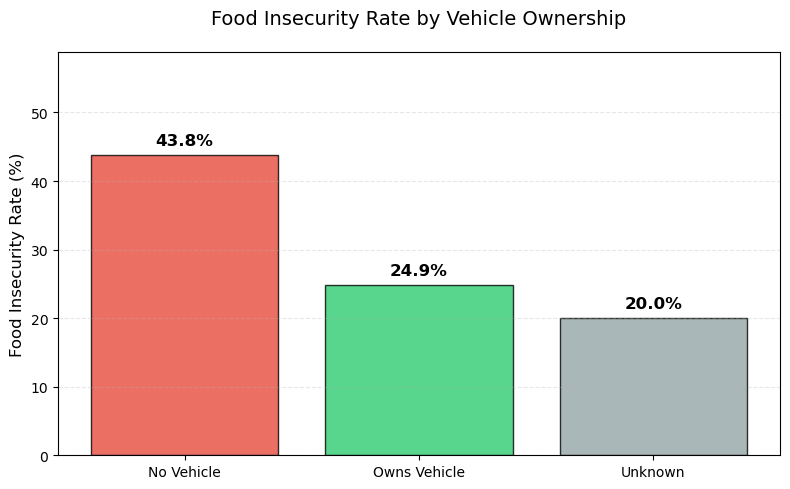

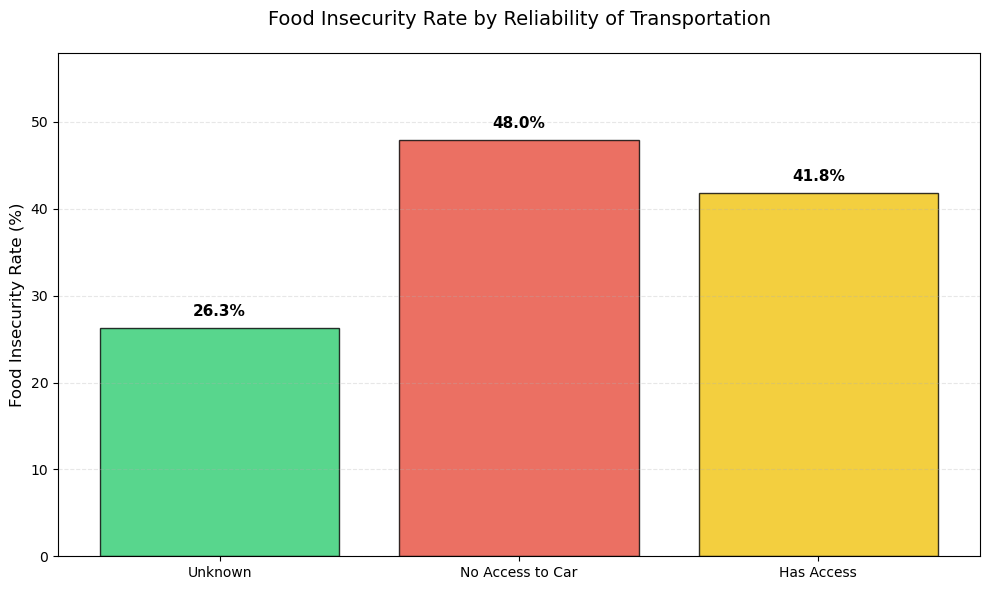

,Insecurity Rate (%)
caraccess,
-996,NaN
0,NaN
1,NaN


In [24]:
# 1. Define specific labels for transportation
TRANSPORT_MAPPINGS = {
    "anyvehicle": {0: "No Vehicle", 1: "Owns Vehicle", -996: "Unknown", -997: "Unknown", -998: "Unknown"},
    "caraccess": {
        0: "No Access to Car", 
        1: "Has Access", 
        -996: "Unknown", 
        -997: "Unknown", 
        -998: "Unknown"
    }
}

def rate_bar_transport_fixed(df, xcol, ycol, title):
    """
    Plots vehicle ownership while grouping technical codes (-998, -997, etc) 
    into a single 'Unknown' category.
    """
    tmp = df[[xcol, ycol]].dropna().copy()
    
    # 1. Map the raw values to labels first
    mapping = TRANSPORT_MAPPINGS.get(xcol, {})
    tmp['labels'] = tmp[xcol].map(lambda x: mapping.get(x, f"Group {x}"))
    
    # 2. Calculate rates based on the labels (this automatically groups 'Unknown' together)
    rate = tmp.groupby('labels')[ycol].mean() * 100
    
    # 3. Sort so 'Owns Vehicle' and 'No Vehicle' come first, 'Unknown' last
    # We define a custom order to keep the chart logical
    custom_order = ["No Vehicle", "Owns Vehicle", "Unknown"]
    rate = rate.reindex([opt for opt in custom_order if opt in rate.index])

    plt.figure(figsize=(8, 5))
    
    # Define colors for the specific labels
    color_map = {"No Vehicle": "#e74c3c", "Owns Vehicle": "#2ecc71", "Unknown": "#95a5a6"}
    colors = [color_map.get(label, "#3498db") for label in rate.index]
    
    bars = plt.bar(rate.index, rate.values, color=colors, edgecolor='black', alpha=0.8)
    
    # Add percentage labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

    plt.title(title, fontsize=14, pad=20)
    plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
    plt.ylim(0, max(rate.values) + 15)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return rate.round(1)

# 2. Binary Comparison: Vehicle Ownership
# This uses the 'rate_bar_assistance' function we updated in the previous step
rate_bar_transport_fixed(df, "anyvehicle", outcome, "Food Insecurity Rate by Vehicle Ownership")

# 3. Categorical Comparison: Car Access
def plot_car_access(df, xcol, ycol):
    tmp = df[[xcol, ycol]].dropna().copy()
    
    # Calculate rates as percentages
    rate = tmp.groupby(xcol)[ycol].mean() * 100
    
    # Map to descriptive labels
    labels = [TRANSPORT_MAPPINGS["caraccess"].get(val, f"Other ({val})") for val in rate.index]
    
    plt.figure(figsize=(10, 6))
    
    # Color logic: Green for Owners, Yellow for Borrowers, Red for No Access
    # Note: We order the colors based on the index of the group (-996, 0, 1)
    colors = ['#2ecc71', '#e74c3c', '#f1c40f'] 
    
    bars = plt.bar(labels, rate.values, color=colors, edgecolor='black', alpha=0.8)
    
    # Add percentage labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.title("Food Insecurity Rate by Reliability of Transportation", fontsize=14, pad=20)
    plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
    plt.ylim(0, max(rate.values) + 10)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return rate.map(TRANSPORT_MAPPINGS["caraccess"]).to_frame(name='Insecurity Rate (%)')

# Run the detailed transportation analysis
plot_car_access(df, "caraccess", outcome)

## The Access Squeeze: Transportation as a Barrier

A major part of the invisible squeeze is how families get to the food they need. While most families in this study own a vehicle, those who do not face a much higher risk of hunger.

### The Car Ownership Gap

The data shows a clear divide between families with a car and those without one. For families who own a vehicle, the rate of hunger is about 25 percent. However, for those without a car, that rate jumps to nearly 44 percent. 

This means that not having a car nearly doubles the risk of hunger. Without a reliable way to get to the store, families are limited in where they can shop. They often cannot reach larger grocery stores with lower prices or buy food in bulk to save money. This creates a physical squeeze on top of the financial one.

Key Insight
Owning a car is a critical tool for staying food secure. It allows families to find the best prices and reach the help they need. Without a car, the simple act of buying groceries becomes a major obstacle that can lead to hunger.

### The Struggle of Borrowing a Ride

Some families who do not own a car try to solve the problem by borrowing a vehicle or getting a ride from others. While this might seem like a solution, the data shows it is often not enough to provide stability.

Families with no access to a car at all face the highest risk, with about 48 percent struggling to get enough food. Even those who can occasionally get a ride or borrow a car still face a very high risk of 42 percent. This suggests that borrowing is not a substitute for having a reliable car of your own. Relying on others makes it difficult to plan trips or buy what is needed, which keeps the family in a state of instability.

Key Insight
Borrowing a car is not the same as owning one. The high rates of hunger for those who rely on others show that transportation must be reliable and consistent to truly help a family stay secure. 

### Summary of Transportation and Hunger
Transportation is a hidden factor that makes the invisible squeeze even worse. While most hungry families have a car, those who do not are at a massive disadvantage. The lack of a reliable vehicle limits a family's choices and makes every trip to the store a challenge. To solve hunger, we must also think about how to bring food closer to the people who cannot easily travel to get it.

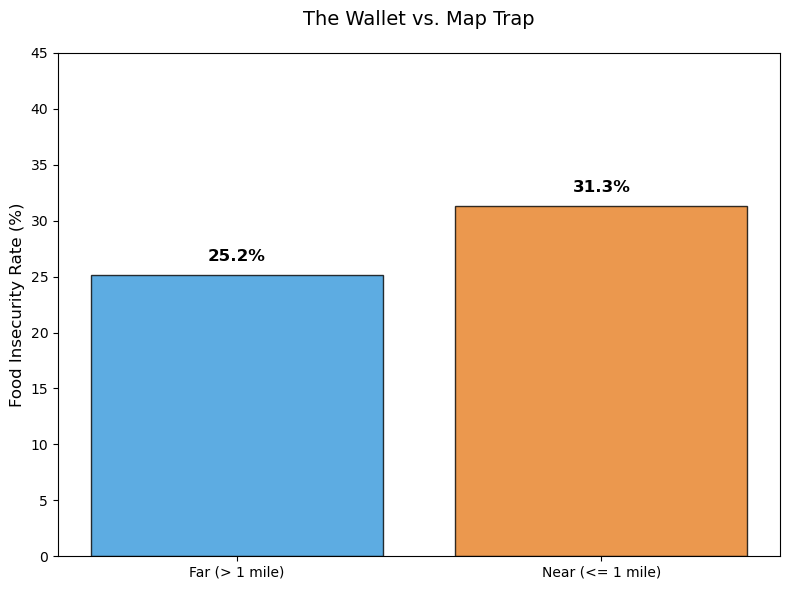

In [34]:
# 1. Categorize distance into Near (within 1 mile) and Far (over 1 mile)
df['store_proximity'] = df['dist_sm'].apply(lambda x: "Near (<= 1 mile)" if x <= 1.0 else "Far (> 1 mile)")
dist_rates = df.groupby('store_proximity')['food_insecure_flag_adult'].mean() * 100

# 2. Create the Visualization
plt.figure(figsize=(8, 6))
# Colors: Blue for Far, Orange for Near
colors = ['#3498db', '#e67e22'] 

bars = plt.bar(dist_rates.index, dist_rates.values, color=colors, edgecolor='black', alpha=0.8)

plt.title("The Wallet vs. Map Trap", fontsize=14, pad=20)
plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
plt.ylim(0, 45)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## The Wallet vs. Map Trap

A common belief is that hunger is caused by "Food Deserts"—neighborhoods that are too far away from a grocery store. However, the data tells a surprising story that challenges this idea.

We found that families living **close** to a supermarket (within 1 mile) actually have a higher rate of hunger (31.3 percent) than those who live further away (25.2 percent). 

This is the "Wallet vs. Map" trap. It proves that simply being close to a store does not protect a family from hunger if they cannot afford the food inside. For many working families, the problem is not the distance to the store, but the high cost of living in areas close to these resources. This reinforces our story: the invisible squeeze is about money, not just location.

Key Insight
Building more grocery stores will not solve hunger on its own. The squeeze is a financial crisis that exists even when food is just a few blocks away.

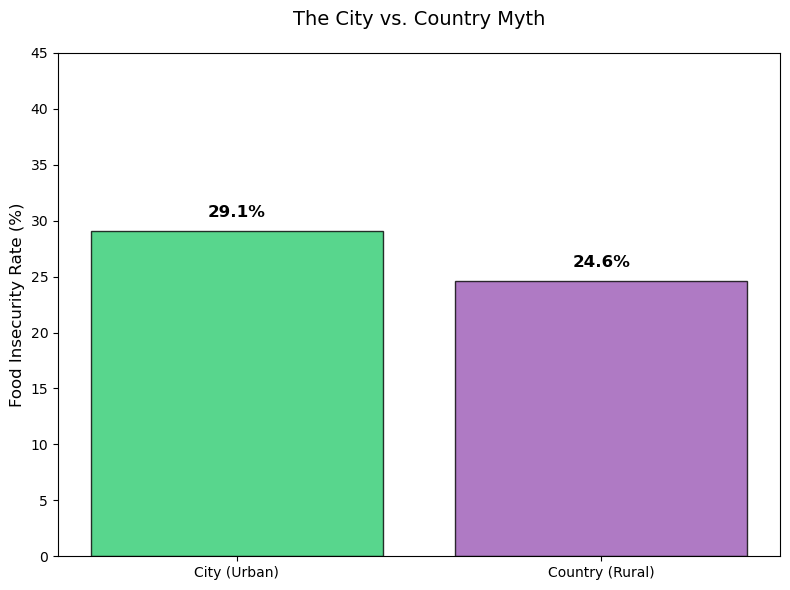

In [35]:
# 1. Map: 0 = City (Urban), 1 = Country (Rural)
df['location_type'] = df['rural'].map({0: "City (Urban)", 1: "Country (Rural)"})
location_rates = df.groupby('location_type')['food_insecure_flag_adult'].mean() * 100

# 2. Create the Visualization
plt.figure(figsize=(8, 6))
# Colors: Green for City, Purple for Country
colors = ['#2ecc71', '#9b59b6'] 

bars = plt.bar(location_rates.index, location_rates.values, color=colors, edgecolor='black', alpha=0.8)

plt.title("The City vs. Country Myth", fontsize=14, pad=20)
plt.ylabel("Food Insecurity Rate (%)", fontsize=12)
plt.ylim(0, 45)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## The City vs. Country Myth

We often imagine that families in rural areas struggle more with hunger because they are isolated from help. But the data shows the opposite.

Families living in the **City (Urban)** areas are facing the invisible squeeze at a higher rate (29 percent) than those in the **Country (Rural)** areas (24.6 percent). 

This suggests that the high cost of city living such as higher rent, expensive transportation, and the general price of goods is creating a tighter squeeze on urban working families. While rural families may face more travel time to get to a store, urban families are being overwhelmed by the basic costs of surviving in a city environment.

Key Insight
Hunger is a major urban crisis. The high cost of city life is a primary driver of the invisible squeeze, pushing even working families into a state of food insecurity.

## 8) Demographic Disparities in Food Insecurity

Food insecurity is influenced not only by income and access to food, but also by demographic characteristics that often reflect broader social and economic inequalities. In this section, we examine food insecurity across three characteristics of the household head:

* Sex
* Race category
* Education level

These factors help identify populations that may face higher vulnerability and may benefit from targeted outreach and support.


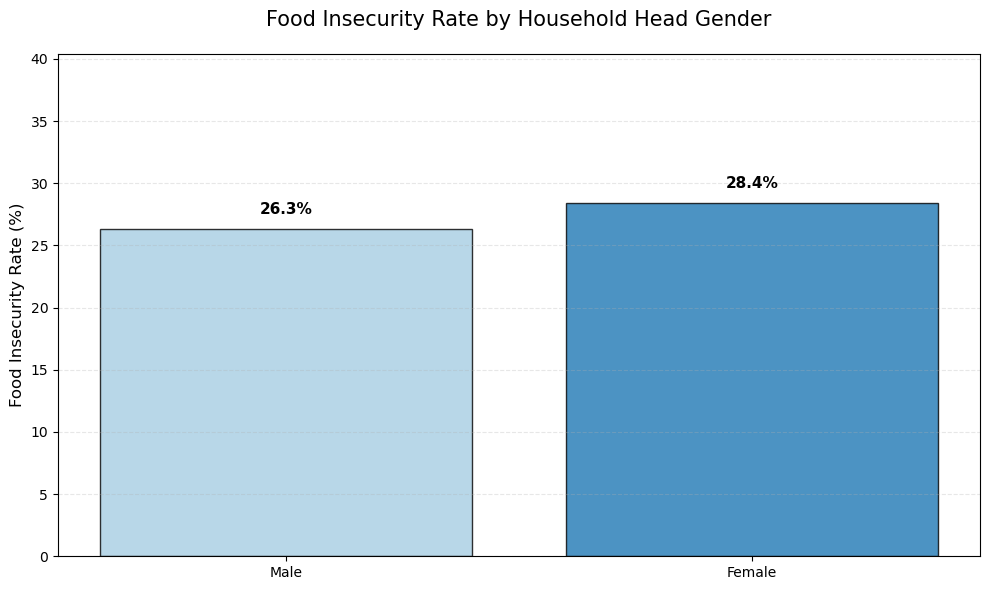

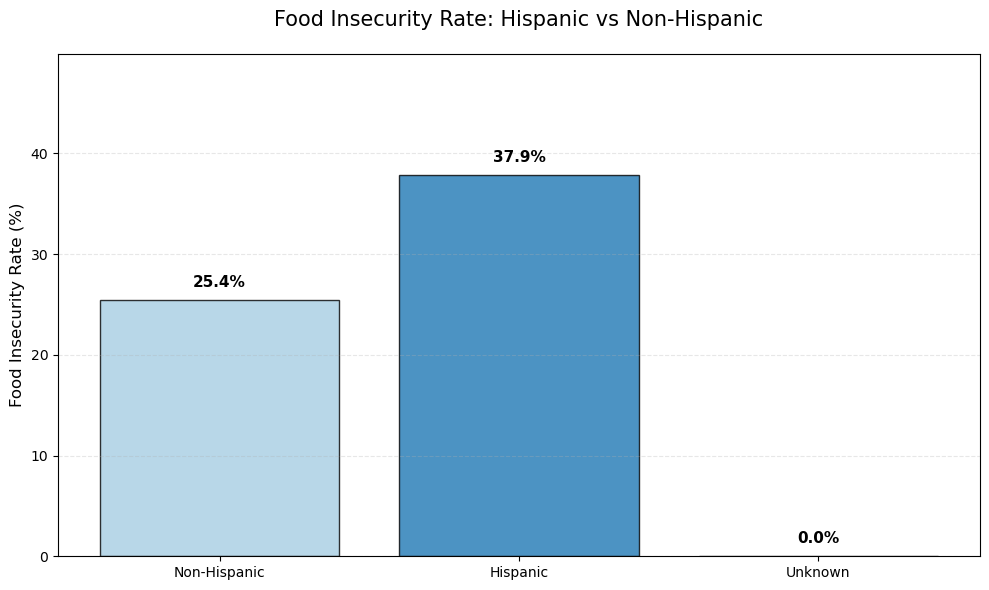

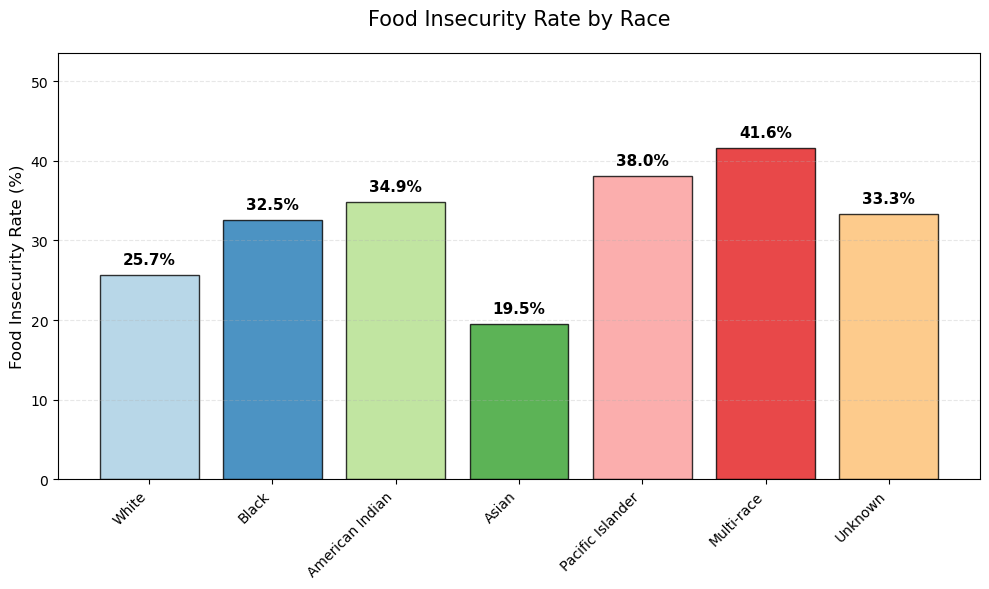

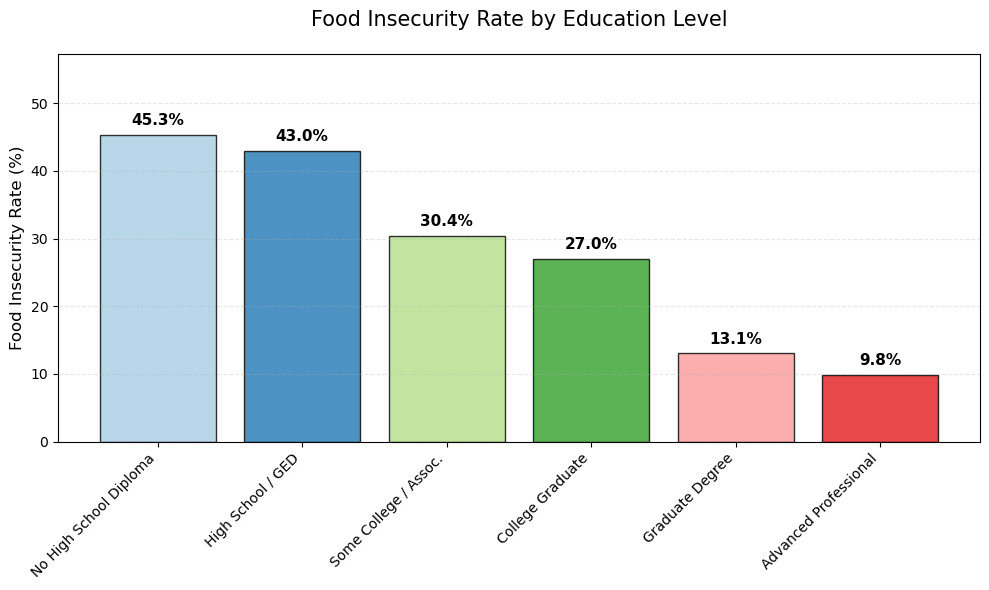

head_educcat
1.0    45.3
2.0    43.0
3.0    30.4
4.0    27.0
5.0    13.1
6.0     9.8
Name: food_insecure_flag_adult, dtype: float64

In [27]:
# Expanded mappings for demographic variables
DEMOGRAPHIC_MAPPINGS = {
    "head_sex": {1: "Male", 2: "Female"},
    "head_hispanic": {0: "Non-Hispanic", 1: "Hispanic", "0": "Non-Hispanic", "1": "Hispanic", "R": "Unknown"},
    "head_racecat": {
        1: "White",
        2: "Black",
        3: "American Indian",
        4: "Asian",
        5: "Pacific Islander",
        6: "Multi-race",
        "1": "White", "2": "Black", "3": "American Indian", "4": "Asian", "5": "Pacific Islander", "6": "Multi-race", "R": "Unknown"
    },
    "head_educcat": {
        1.0: "No High School Diploma",
        2.0: "High School / GED",
        3.0: "Some College / Assoc.",
        4.0: "College Graduate",
        5.0: "Graduate Degree",
        6.0: "Advanced Professional"
    }
}


def rate_bar_demographics(df, xcol, ycol, title, rotate=0):
    """
    Plots demographic food insecurity rates with clear text labels and visual polish.
    """
    tmp = df[[xcol, ycol]].dropna().copy()
    
    # Calculate the rate as a percentage
    rate = tmp.groupby(xcol)[ycol].mean() * 100
    
    # Map raw codes to descriptive text
    mapping = DEMOGRAPHIC_MAPPINGS.get(xcol, {})
    labels = [mapping.get(val, f"Group {val}") for val in rate.index]

    plt.figure(figsize=(10, 6))
    
    # Use a varied color palette for categorical demographics
    colors = plt.cm.Paired(range(len(labels)))
    bars = plt.bar(labels, rate.values, color=colors, edgecolor='black', alpha=0.8)
    
    # Add percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.title(title, fontsize=15, pad=20)
    plt.ylabel('Food Insecurity Rate (%)', fontsize=12)
    plt.xticks(rotation=rotate, ha='right' if rotate > 0 else 'center')
    plt.ylim(0, max(rate.values) + 12) 
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return rate.round(1)



# 1. Gender Disparity
rate_bar_demographics(df, "head_sex", outcome, "Food Insecurity Rate by Household Head Gender")

# 2. Ethnic Disparity
rate_bar_demographics(df, "head_hispanic", outcome, "Food Insecurity Rate: Hispanic vs Non-Hispanic")

# 3. Racial Disparity (Requires 45-degree rotation for labels)
rate_bar_demographics(df, "head_racecat", outcome, "Food Insecurity Rate by Race", rotate=45)

# 4. The Education Gap (Crucial for the 'Story')
rate_bar_demographics(df, "head_educcat", outcome, "Food Insecurity Rate by Education Level", rotate=45)


## Understanding the Assumptions Behind the Story

To uncover the hidden reality of the working hungry, we have interpreted the data through a specific lens. It is important to acknowledge these assumptions to provide a complete and honest picture of the invisible squeeze.

### 1. The SNAP Paradox
We noticed that hunger rates are similar for those receiving government food assistance and those who are not.

**The Assumption:** We assume that families on SNAP are naturally more vulnerable than those who are not. 

**The Context:** If the program is working, we expect it to "stabilize" the family. The fact that their hunger levels are equal to others suggests the program is acting as a vital lifeline, preventing these families from falling into even deeper crisis, even if it cannot fully solve the problem of hunger.

### 2. The Stability of Older Adults
Our data showed that homes with seniors are often more food secure.

**The Assumption:** We assume this is due to the steady nature of retirement income.

**The Context:** While the data points to this stability, it is also possible that older adults have different spending habits, lower housing costs, or more experience with long-term budgeting. We view their steady income as a "shield" that protects them from the sudden economic shifts that affect younger, working families.

### 3. The Link Between Access and Hunger
We found that families without cars face nearly double the risk of hunger.

**The Assumption:** We assume that the lack of a car is a direct barrier to getting affordable food.

**The Context:** In reality, transportation and money are often linked. A family that cannot afford a car likely also struggles with other costs. We treat the car as a "tool for security," assuming that physical access to stores is a primary driver of a family's ability to stay fed.



### 4. The Role of Education
The data shows a clear "staircase" where more schooling leads to significantly less hunger.

**The Assumption:** We assume education is the primary driver of this stability.

**The Context:** Education is often a stand-in for many things at once, including higher pay, better job benefits like health insurance, and stronger professional networks. We assume that schooling is the "protector," but it is actually the gateway to a much larger package of economic safety.

### 5. Categorizing the Unknown
In our analysis of transportation, we grouped several technical survey codes into a single "Unknown" category.

**The Assumption:** We assume this group does not hold a hidden story that contradicts our main findings.

**The Context:** By focusing on the clear "Yes" and "No" answers, we are able to tell a clear story. We assume that the patterns we see in the known data are a true reflection of the struggle facing the entire community.


In conclusion, these assumptions allow us to move from raw numbers to a human story. By recognizing these factors, we can better understand that the invisible squeeze is not caused by one single issue, but by a combination of income, access, and stability.

## Gender and the Squeeze

When we look at whether a man or a woman leads the home we see that the rates of hunger are very similar. Homes led by men have a hunger rate of about 26 percent while those led by women are slightly higher at around 29 percent. This small difference shows that while women led homes may face a slightly harder time the economic squeeze is felt by almost everyone regardless of gender.

Key Insight
Hunger is a broad problem that affects both men and women. While there is a small gap the most important factors for staying secure are likely tied to money and jobs rather than gender alone.

## Differences Across Communities

The invisible squeeze does not hit every community in the same way. When we look at the background of the person leading the home we see large differences in the risk of hunger. Some groups face much higher rates of struggle than others.

For example households led by Asian people have the lowest rate at about 20 percent and White led households are at 26 percent. However the rates rise significantly for other groups. Black led households face a 32 percent risk and American Indian led households are at 35 percent. The highest rates are seen in Pacific Islander homes at 38 percent and homes with a multi race background at 42 percent.

These numbers show that the squeeze is nearly twice as hard for some families depending on their community. These differences often reflect broader obstacles that some groups face when trying to build financial stability.

Key Insight
Hunger is felt much more deeply in certain communities. To truly solve the problem we must ensure that help reaches the groups that are facing the highest levels of risk.

## Schooling as a Shield

One of the most powerful ways a person can protect their family from the invisible squeeze is through education. The data shows a very clear and strong pattern. As the level of schooling increases the risk of hunger drops dramatically.

For those without a high school diploma the rate of hunger is very high at about 45 percent. Having a high school diploma only lowers that slightly to 43 percent. However the protection grows much stronger with more education. Families led by college graduates have a hunger rate of 27 percent and those with advanced professional degrees have the lowest risk at only 10 percent.

This staircase effect shows that schooling is a key factor in finding stable work and better pay which are the best defenses against hunger.

Key Insight
Education is the strongest shield we have found against the invisible squeeze. Helping people gain more skills and schooling is a long term way to lift families out of the cycle of hunger.

## The Uneven Reach of Hunger

The information we have gathered shows that hunger is not spread evenly across our neighbors. While gender plays a small role the biggest differences are found in community backgrounds and education levels. 

Some communities face nearly double the risk of others showing that the squeeze is much tighter for them. At the same time schooling acts as a powerful protector. These patterns help us see exactly where the invisible squeeze is hurting people the most so we can focus our help where it is needed most.